In [3]:
import subprocess 
import contextlib
from utils.data import MalwareDataset
from tqdm import tqdm 
import concurrent.futures
import multiprocess
from typing import Callable, List, Tuple, Any
import matplotlib.pyplot as plt 
import numpy as np 
from scipy.stats import norm 
import angr 
import json
import string
from collections import Counter
import os 
import networkx as nx

ERROR_SENTINAL = -100

def process_dataset(dataset: List[Tuple[str, int]], fn: Callable, num_workers: int = 4):
    malware, benign = [], []

    with concurrent.futures.ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(tqdm(executor.map(fn, dataset), total=len(dataset)))

    for label, metric in results:
        if metric == ERROR_SENTINAL: 
            continue
         
        if label == 1:
            malware.append(metric)
        else:
            benign.append(metric)

    return malware, benign


dataset = MalwareDataset() 

# Opcode Frequency 

In [5]:
base_path = '/Volumes/New Volume/malware-detection-dataset/opcodes/processed-data'

opcode_table = json.load(open("/Users/henrywilliams/Documents/uni/masters-thesis/src/classifiers/static/opcode-transformer/vocab_table.json", "r"))

def make_counter():
    counter = {}
    for key in opcode_table:
        counter[key] = 0 
    return Counter(counter)

def get_data(path: os.PathLike, full_path: bool = True) -> List[str]:
    all_files = os.listdir(path)
    
    if full_path:
        return [os.path.join(path, file) for file in all_files if file.endswith('.txt')]
    else: 
        return all_files

def get_labels(filenames):
    return [1 if "VirusShare" in filename else 0 for filename in filenames]

def analyse_frequency(path):
    table = make_counter()
    with open(path, "r") as f: 
        lines = f.read().splitlines()

    total_instrs = len(lines)
    table.update(lines)

    if total_instrs <= 0: 
        return table 

    for instr, _ in table.items():
        table[instr] /= total_instrs
        
    return table

def handle_opcode_freq(x):
    return x[1], analyse_frequency(x[0])

paths = get_data(base_path)
labels = get_labels(get_data(base_path, False))
ds = [(path, label) for path, label in zip(paths, labels)]

mal_count, ben_count = process_dataset(ds, handle_opcode_freq, num_workers=8)

100%|██████████| 6940/6940 [00:48<00:00, 142.96it/s]


In [6]:
mal_freq = make_counter() 
ben_freq = make_counter() 
opcode_freq = make_counter() 

for opcode in tqdm(mal_freq): 
    mal_freq[opcode] = np.mean([cnt[opcode] for cnt in mal_count])
    ben_freq[opcode] = np.mean([cnt[opcode] for cnt in ben_count])
    opcode_freq[opcode] = (mal_freq[opcode] + ben_freq[opcode]) / 2

100%|██████████| 1293/1293 [00:03<00:00, 392.64it/s]


In [ ]:
mal = np.array(list(mal_freq.values()))
ben = np.array(list(ben_freq.values()))
(mal @ ben) / (np.linalg.norm(mal) * np.linalg.norm(ben))

# Entropy Analysis 

In [ ]:
def get_entropy(path: str):
    output = subprocess.run(["rahash2", "-a entropy", path], capture_output=True).stdout.decode('utf-8')
    parts = output.split(":")
    return float(parts[-1].strip())

def handle_entropy(x):
    try: 
        return x[1], get_entropy(x[0])
    except: 
        return x[1], ERROR_SENTINAL

malware_entropy, benign_entropy = process_dataset(dataset, handle_entropy, num_workers=8)

100%|██████████| 11115/11115 [00:57<00:00, 194.80it/s]


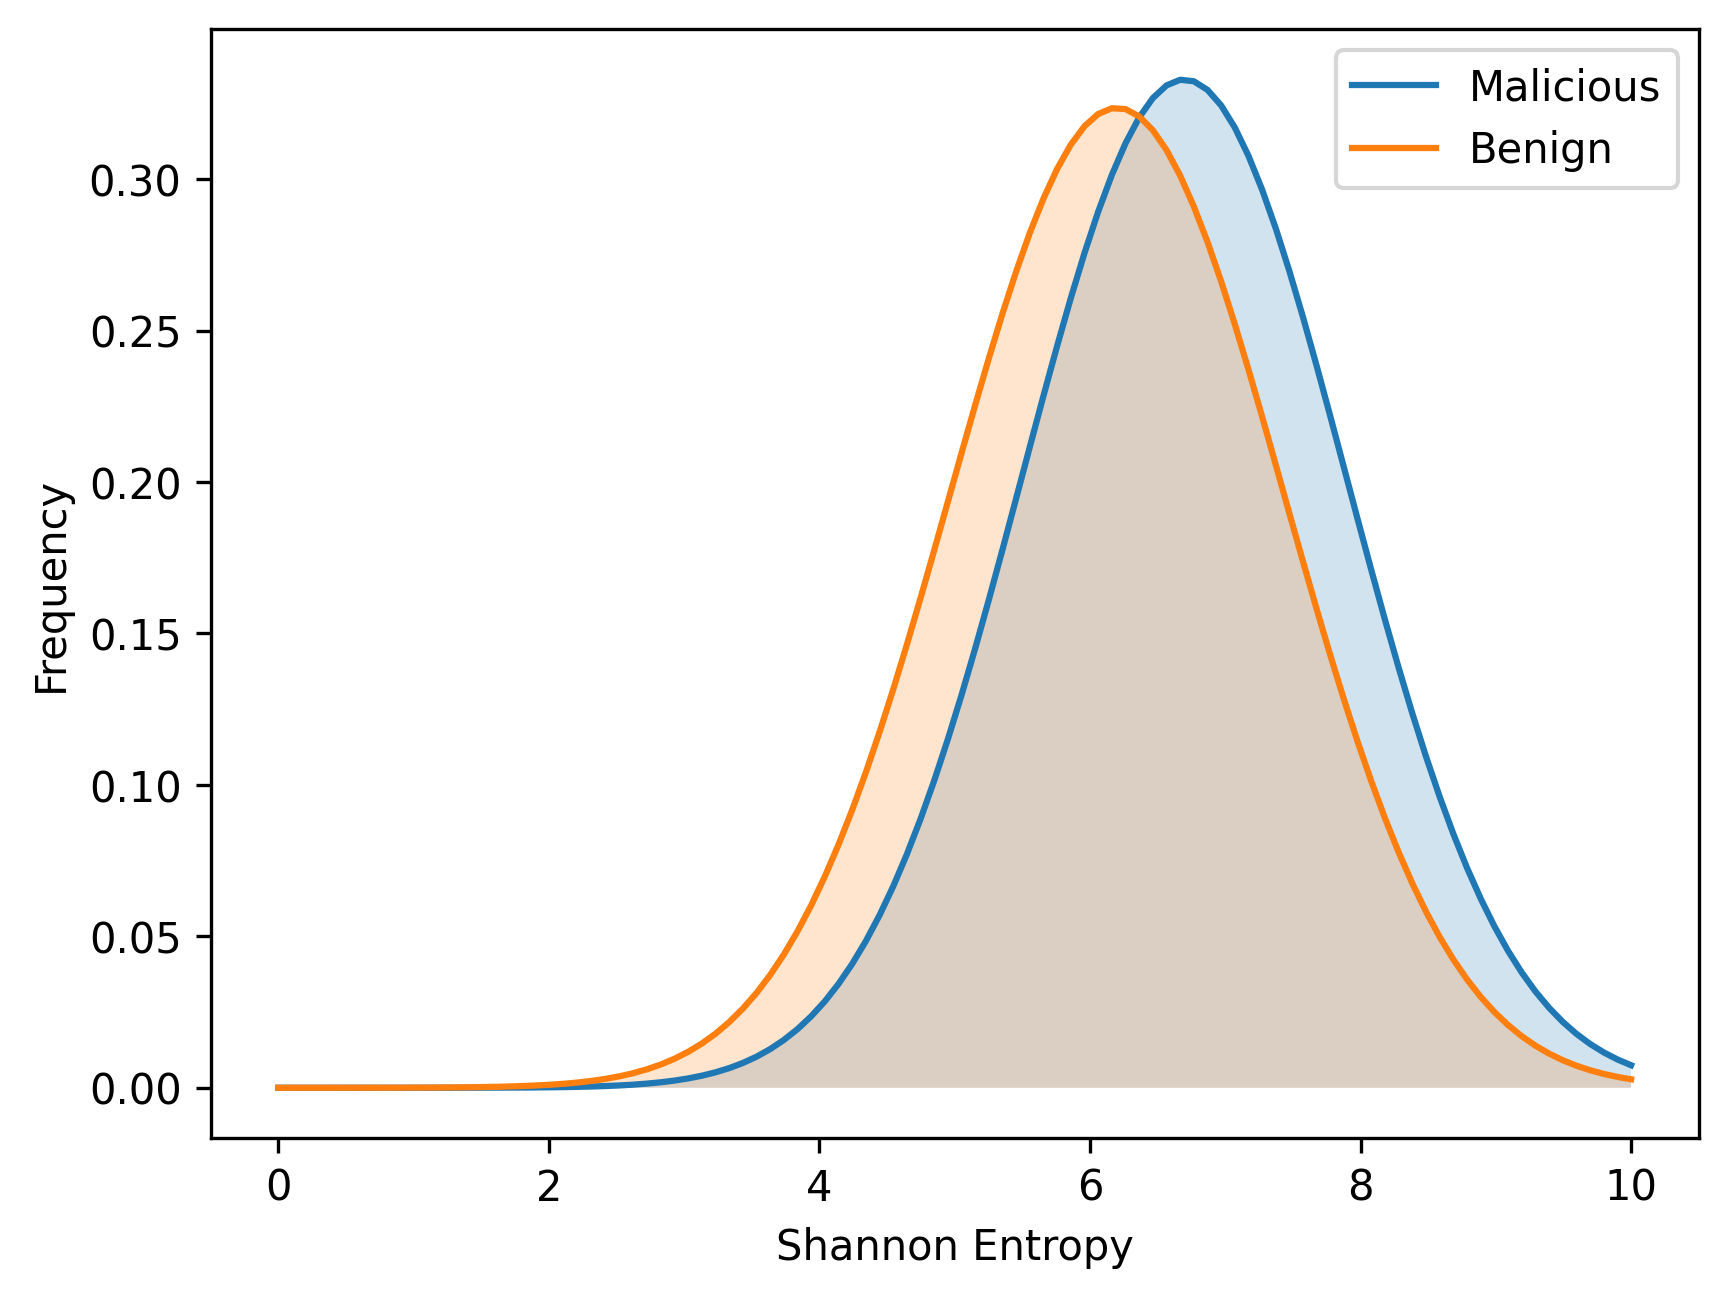

In [ ]:

x = np.linspace(0, 10, 100)
mu_m, std_m = np.mean(malware_entropy), np.std(malware_entropy)
mu_b, std_b = np.mean(benign_entropy), np.std(benign_entropy)

p_e_m = norm.pdf(x, mu_m, std_m)
p_e_b = norm.pdf(x, mu_b, std_b)
plt.figure(dpi=300)
plt.plot(x, p_e_m, label="Malicious", c="tab:red")
plt.fill_between(x, 0, p_e_m, alpha=0.2)
plt.plot(x, p_e_b, label="Benign", c="tab:blue")
plt.fill_between(x, 0, p_e_b, alpha=0.2)
plt.xlabel("Shannon Entropy")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# String Entropy Analysis

In [ ]:
def get_string_entropy(path: str):
    out = subprocess.run(['strings', path], capture_output=True).stdout.decode('utf-8')
    data = '\n'.join(out)
    freq = Counter(data)
    entropy = 0 
    
    for c in string.printable: 
        p_c = float(freq.get(c, 0) / len(data))

        if p_c > 0: 
            entropy += -p_c * np.log2(p_c)

    return entropy 

def handle_string_entropy(x):
    try: 
        return x[1], get_string_entropy(x[0])
    except: 
        return x[1], ERROR_SENTINAL

mal_str_entropy, ben_str_entropy = process_dataset(dataset, handle_string_entropy, num_workers=8)

100%|██████████| 11115/11115 [04:09<00:00, 44.51it/s] 


(np.float64(3.6725633120476027), np.float64(3.5337748075467306))

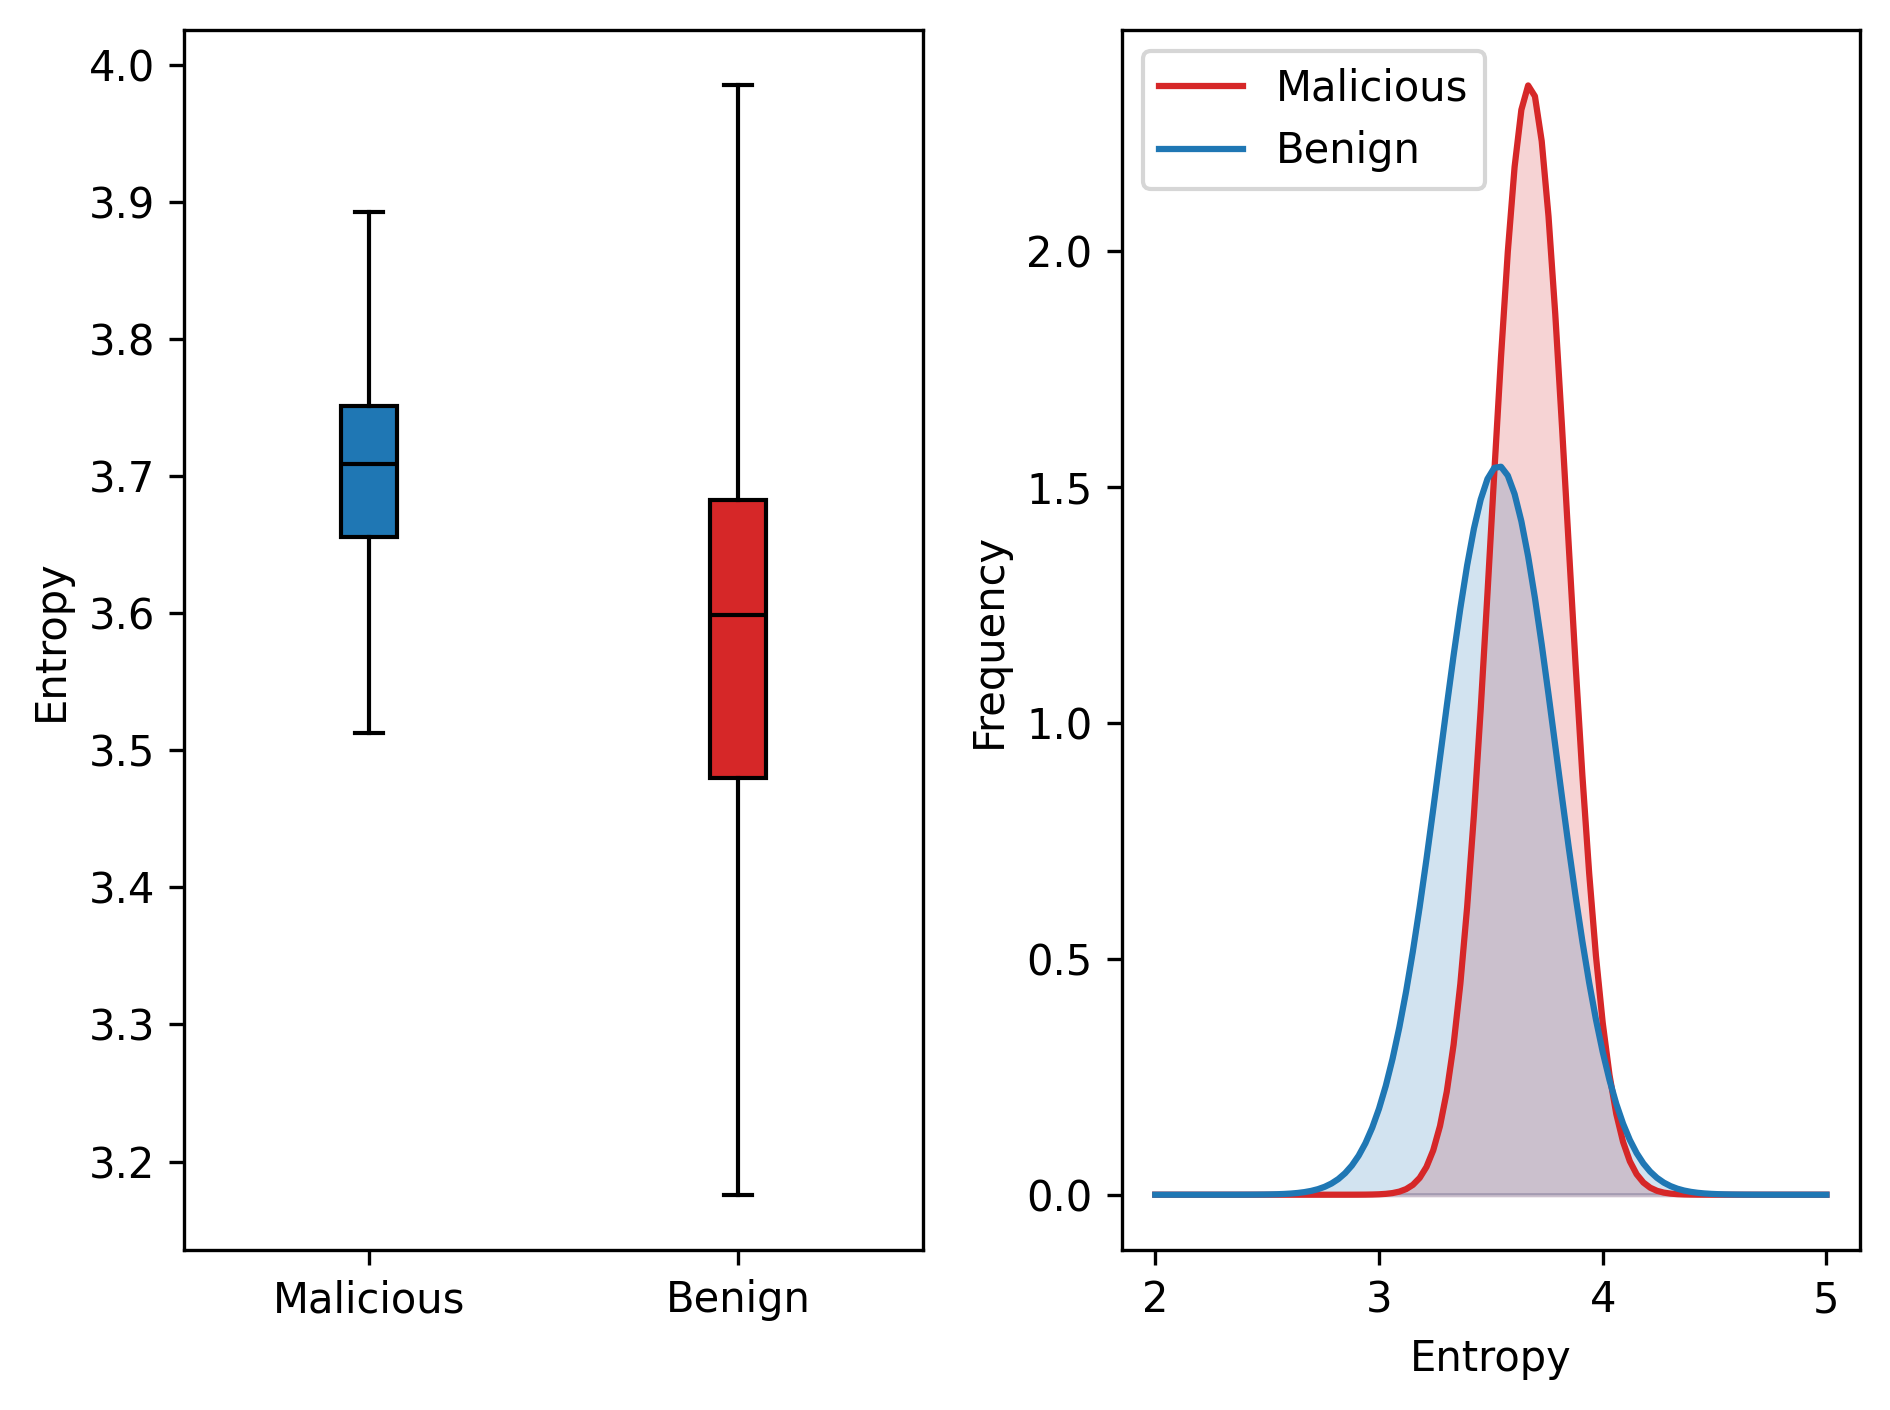

In [25]:
fig, axs = plt.subplots(1, 2, dpi=300)
fig.set_tight_layout(True)
bp = axs[0].boxplot(
    [mal_str_entropy, ben_str_entropy],
    vert=True,
    patch_artist=True,
    tick_labels=["Malicious", "Benign"],
    medianprops={"color": "black"},
    sym="",
)
for box, color in zip(bp["boxes"], ["tab:blue", "tab:red"]):
    box.set(facecolor=color)

axs[0].set_ylabel("Entropy")

x = np.linspace(2, 5, 100)

mu_sm, std_sm = np.mean(mal_str_entropy), np.std(mal_str_entropy)
mu_sb, std_sb = np.mean(ben_str_entropy), np.std(ben_str_entropy)

p_e_m = norm.pdf(x, mu_sm, std_sm)
p_e_b = norm.pdf(x, mu_sb, std_sb)
axs[1].plot(x, p_e_m, label="Malicious", c="tab:red")
axs[1].fill_between(x, 0, p_e_m, alpha=0.2, color='tab:red')
axs[1].plot(x, p_e_b, label="Benign", c="tab:blue")
axs[1].fill_between(x, 0, p_e_b, alpha=0.2, color='tab:blue')
axs[1].set_xlabel("Entropy")
axs[1].set_ylabel("Frequency")
axs[1].legend()

plt.show()


# Control Flow Graph 

TypeError: 'int' object is not iterable

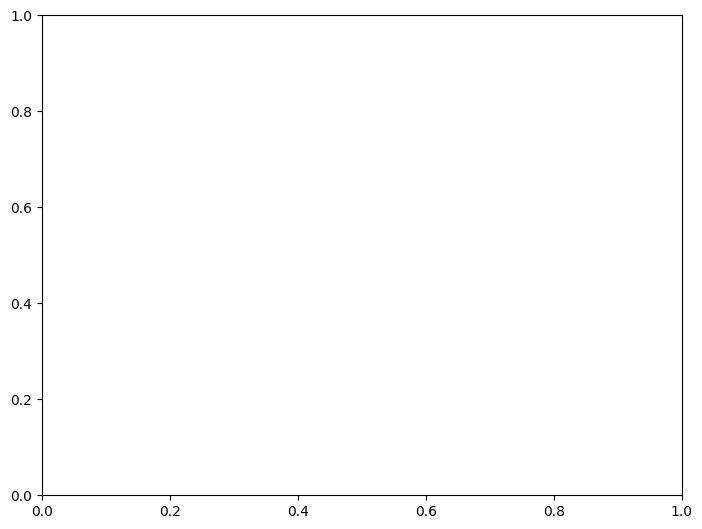

In [ ]:
import logging 
# logging.getLogger('angr').setLevel("CRITICAL")
logging.getLogger().setLevel("CRITICAL")
# logging.getLogger('claripy').setLevel("CRITICAL")
def get_cfg_metrics_worker(path: str, queue: multiprocess.Queue) -> None:
    try:
        proj = angr.Project(path, load_options={'auto_load_libs': False})
        cfg = proj.analyses.CFGFast(force_complete_scan=False, normalize=True, resolve_indirect_jumps=False, start_at_entry=True)
        queue.put(cfg.graph) 
    except Exception:
        queue.put(nx.DiGraph())  

def get_cfg_metrics(path: str, timeout: int = 60) -> Any:
    queue = multiprocess.Queue()
    process = multiprocess.Process(target=get_cfg_metrics_worker, args=(path, queue))
    
    process.start()
    process.join(timeout)  
    
    if process.is_alive():
        process.terminate()  
        process.join()  
        return ERROR_SENTINAL

    return queue.get() if not queue.empty() else nx.DiGraph()  

def handle_cfg(entry: Tuple[str, int]) -> Tuple[int, Tuple[int, int]]:
    path, label = entry
    return label, get_cfg_metrics(path)

G = get_cfg_metrics("/Volumes/New Volume/malware-detection-dataset/malware/VirusShare_2ac01cab7b8ce648694883b4683f44f0")
nx.draw(G)